## Example 2: ElectroMagnetic GPR Model Generation

This example demonstrates the use of **ModGen2D** to generate spatially correlated electromagnetic property fields for a typical **ground-penetrating radar (GPR)** modeling scenario.

In this notebook, we:
- Construct a two-dimensional subsurface model with a prescribed number of geological layers and a defined groundwater table.
- Impose deterministic lithological constraints to control key interfaces within the domain.
- Generate a shared stochastic field to introduce spatial variability.
- **Special Case** - Use a user-defined bivariate random generator to produce correlated electromagnetic properties, specifically dielectric permittivity (ε) and electrical conductivity (σ).
- **Special Case** - Fixed a 1D lithological boundary at x = 2.5 m to enforce a hybrid interface (stochastic, with 1D constraint).

This example highlights ModGen2D’s ability to generate physically consistent, spatially heterogeneous electromagnetic models suitable for uncertainty quantification, sensitivity analysis, inversion benchmarking, and synthetic data generation for AI/ML applications.

In [1]:
import pandas as pd
import numpy as np
import modgen2d as mg
import example2_helper_functions as hf

seed = 17

## Step 1: Unit Configuration

Define the units for the computational process. There are **two units**:

- **`domain_length_unit`** (`str`)  
  - Unit used **internally** by the computational domain (e.g., `'cm'`).  
  - Typically **smaller** or discretized so that all domain lengths (spans, dls) are **integers** in this unit.

- **`physical_length_unit`** (`str`)  
  - Unit used **externally** by the user (e.g., `'m'`).  
  - Represents the **real-world scale** and is used throughout for input/output.

> Note: All computations are performed in the **domain unit**, but all user interactions use the **physical unit**.


In [2]:
units_config = mg.Units("m", "cm", conversion_factor=100) #mg.Units() also have same arg values

## Step 2: Properties Definition

In this step, we define the **features and their properties** within the domain.  

Properties can become as complex as needed, depending on:
- The number of **feature types** (e.g., soil, utilities, karst)
- The number of sub-types of each features.
- Conditions of the features (e.g., wet/dry soils)
- Type of random generators for each feature (Uniform, Constant etc.)

Since, in this example, we have multiple sub-types for soils, and each have their own wet/dry soils properties. We will create a helper function to add material using **csv_file**. For more simpler example, refer to Example 3: Large geology.

For simplicity, this example splits Step 2 into **four sub-steps**:
1. **General Definitions** – basic setup and parameters.  
2. **Feature Configuration** – define which materials belong to which features.  
3. **Main Properties** – assign physical properties like density, velocity, etc.  
4. **Auxiliary Properties** – any extra properties needed for modeling.

### Step2.1: General Definitions

In [3]:
# Domain dimensions
x_span = 5          # Domain length in X-direction (domain units)
z_span = 3          # Domain depth in Z-direction (domain units)

# Grid spacing
del_xz_spatial = 0.2     # Base spacing for the domain for interfaces (spatial correlation)
del_xz_final = 0.1       # Base spacing for the domain for obstacles and final generated model.
del_xz_obs = del_xz_final / 10  # Finer spacing for obstacles (recommended: 1/10)

# Interface interpolation method
remesh_interp_method = 'linear'

# Spatial correlation parameters
spatial_theta_x = 100  # Correlation length in X
spatial_theta_z = 0.5  # Correlation length in Z

# Random number generator (for reproducibility)
rng = np.random.default_rng(seed=seed)

### Step 2.2: Features Configuration

In [4]:
# Initialize feature configuration
feature_config_instance =  mg.FeaturesConfig()

# Define material distributions for this simple example
# For this example, there are only one material type for soil - "generic soil", and utilities - "PVC"
# Note: these distributions must be random_generators: Hence, using "Constant".
soil_materials_distribution = mg.random_generators.Constant(val = 'sand', rng=rng)
utils_materials_distribution = mg.random_generators.Constant(val = 'PVC', rng=rng)

# Add features to feature_config_instance
feature_config_instance.add_feature('def', soil_materials_distribution, feature_description = 'def means soil.')
feature_config_instance.add_feature('U', utils_materials_distribution, feature_description = 'utility features')

### Step 2.3: Main Properties

In this step, we define **main physical properties** for each feature in the domain (e.g., shear wave velocity `vs`).
Main property refers to all the properties that is to be "simulated".

Each property can have different values for wet and dry conditions. 
- **Wet / Both conditions**  - If dry condition is not provided (is None), then it refers to "both". ie (wet and dry condition are same)
- **Dry conditions** (optional)  

We also define **layer0 values**, which represent property values of **water if wet; air if dry**; needed if the model has a **non-horizontal ground surface**, so layer0 properties are applied accordingly.

In [5]:
#2.3.1 Main Properties config definition
main_properties_config_instance =  mg.MainPropertiesConfig(feature_config_instance, layer0_flag=False)

#2.3.2 Define each MainProperty instance
main_property_name = 'ec'
property_desc = 'electric conductivity'
main_property_instance = mg.MainProperty(main_property_name, feature_config_instance, layer0_flag=False, description=property_desc)

#2.3.3  Define wet and dry properties for each features' each materials (including layer 0  for 'def' if flag is True)
## For Feature 'def'; material type 'sand'
corr_coeff = 0.78

# NOTE: This generator produces two values (Ec and dc) in a single go. Hence, additional post-processing is needed to adjust to format later.
wet_mean_distribution = hf.CorrelatedUniformBivariateXLogY(20, 30, 0.1, 1, corr_coeff, rng)  
dry_mean_distribution = hf.CorrelatedUniformBivariateXLogY(3, 5, 0.01, 0.01, corr_coeff, rng)
cov_distribution = mg.random_generators.Constant(0.05, rng)
cov_type = 'cov'
wet_prop = mg.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)
dry_prop = mg.PropertyDistribution(main_property_name,  dry_mean_distribution, cov_distribution, stdev_type=cov_type)

main_property_instance.add_material_property_of_feature(feature_id='def', material_name='sand', #Must match feature_id and material name (as defined in features_config)
                                                        property_distribution_instance=wet_prop,  
                                                        property_distribution_instance_if_dry=dry_prop 
                                                       )

## For Feature 'utils'; material type 'PVC'
corr_coeff = 0.78
wet_mean_distribution = hf.CorrelatedUniformBivariateXLogY(3, 5, 0.001, 0.001, corr_coeff, rng)
dry_mean_distribution = None
cov_distribution = None
cov_type = 'cov'
wet_prop = mg.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)
dry_prop = None

main_property_instance.add_material_property_of_feature(feature_id='U', material_name='PVC',
                                                        property_distribution_instance=wet_prop, 
                                                        property_distribution_instance_if_dry=dry_prop)


# 2.3.4 Add MainProperty to MainPropertiesConfig instance
main_properties_config_instance.add_main_property(main_property_instance)




### Repeat for 'dc'
## But since 'dc' is already generated from the bivariate random generator above, so this is defined for a placeholder in sampled properties only.
#2.3.2 Define each MainProperty instance
main_property_name = 'dc'
property_desc = 'dielectric constant'
main_property_instance = mg.MainProperty(main_property_name, feature_config_instance, layer0_flag=False, description=property_desc)

#2.3.3  Define wet and dry properties for each features' each materials (including layer 0  for 'def' if flag is True)
## For Feature 'def'; material type 'sand'

# NOTE: Just a placeholder. Additional post-processing is needed to adjust to the format later.
wet_mean_distribution = mg.random_generators.Constant(-999, rng)  # Filler to be replaced later
dry_mean_distribution = mg.random_generators.Constant(-999, rng)  # Filler to be replaced later
cov_distribution = mg.random_generators.Constant(0.05, rng)
cov_type = 'cov'
wet_prop = mg.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)
dry_prop = mg.PropertyDistribution(main_property_name,  dry_mean_distribution, cov_distribution, stdev_type=cov_type)
main_property_instance.add_material_property_of_feature(feature_id='def', material_name='sand',
                                                        property_distribution_instance=wet_prop,
                                                        property_distribution_instance_if_dry=dry_prop)

## For Feature 'utils'; material type 'PVC'
wet_mean_distribution = mg.random_generators.Constant(-999, rng)  # Filler to be replaced later
dry_mean_distribution = None
cov_distribution = None
cov_type = 'cov'
wet_prop = mg.PropertyDistribution(main_property_name,  wet_mean_distribution, cov_distribution, stdev_type=cov_type)
dry_prop = None

main_property_instance.add_material_property_of_feature(feature_id='U', material_name='PVC',
                                                        property_distribution_instance=wet_prop, 
                                                        property_distribution_instance_if_dry=dry_prop)

# 2.3.4 Add MainProperty to MainPropertiesConfig instance
main_properties_config_instance.add_main_property(main_property_instance)

main_properties_config_instance.print()

Main_Properties: ['ec', 'dc']
feature_ids: ['def', 'U']
---------------------------
Property Name: ec
Description: electric conductivity
All Feature IDs: ['def', 'U']
Properties:
{'def': {'sand': {'wet': <modgen2d.property_distribution.PropertyDistribution object at 0x000001A2CC800D10>,
                  'dry': <modgen2d.property_distribution.PropertyDistribution object at 0x000001A2CC800950>}},
 'U': {'PVC': {'both': <modgen2d.property_distribution.PropertyDistribution object at 0x000001A2CC801760>}}}
---------------------------
Property Name: dc
Description: dielectric constant
All Feature IDs: ['def', 'U']
Properties:
{'def': {'sand': {'wet': <modgen2d.property_distribution.PropertyDistribution object at 0x000001A2CC8018A0>,
                  'dry': <modgen2d.property_distribution.PropertyDistribution object at 0x000001A2CC801B70>}},
 'U': {'PVC': {'both': <modgen2d.property_distribution.PropertyDistribution object at 0x000001A2CC801C10>}}}


In [6]:
main_properties_config_instance.main_properties['ec'].generate_sample_dict('def', 'sand')

{'wet': {'mean': array([[29.08217004,  0.67319419]]),
  'mean_bm': 0,
  'stdev_or_cov': 0.05,
  'stdev_type': 'cov'},
 'dry': {'mean': array([[4.37524887, 0.01      ]]),
  'mean_bm': 0,
  'stdev_or_cov': 0.05,
  'stdev_type': 'cov'}}

In [7]:
## As shown in sample dict above:: Ec dict, have generated two correlated samples, one for ec and another for dc. Hence, adjusting this for format is needed and done below.

### Step 2.4: Auxiliary Properties

Auxiliary properties are not simulated directly but are required for model generation like number of soil layers, etc.
Think of auxiliary properties as a collection of random generators or configuration values that support the simulation.

You can define them using a dictionary too.

In [8]:
# Define some additional Properties
aux_props = mg.AuxillaryProperties()
aux_props.add_aux_property('n_layers',  mg.random_generators.DiscreteChoice(x=[4], p=[1], rng=rng))
aux_props.add_aux_property('gwt', mg.random_generators.Uniform(2, 2, rng))

utilities_sett={
    'n_obs': mg.random_generators.DiscreteChoice([0,1], p = [0.2, 0.8], rng=rng),
    'obs_shape': mg.random_generators.DiscreteChoice(['circ2d', 'rect2d',], [1/2, 1/2], rng=rng),
    'dia_obs':mg.random_generators.Uniform(0.3, 1, rng=rng), 
    'lh_obs':mg.random_generators.Uniform(0.3, 1, rng=rng), 
    'obs_x_coord':mg.random_generators.Uniform(0, x_span, rng=rng), 
    'depth_top_dist':hf.Discrete2ContinuousPDF([0,5], p = [1,.2], new_del_x = 1, rng=rng), #Continuous distribution: discrete to be converted into continuous: also
}

aux_props.add_aux_property('n_obs', utilities_sett['n_obs'])
aux_props.add_aux_property('obs_shape', utilities_sett['obs_shape'])
aux_props.add_aux_property('dia_obs', utilities_sett['dia_obs'])
aux_props.add_aux_property('lh_obs', utilities_sett['lh_obs'])
aux_props.add_aux_property('obs_x_coord', utilities_sett['obs_x_coord'])
aux_props.add_aux_property('depth_top_utils', utilities_sett['depth_top_dist'])
    
aux_props.print()

Additional_Properties: dict_keys(['n_layers', 'gwt', 'n_obs', 'obs_shape', 'dia_obs', 'lh_obs', 'obs_x_coord', 'depth_top_utils'])


## Step 3: Model Definition

In this step, we define the computation **domain2d**, **geological interfaces**, **2D lithological model**, and simulation of **generated model2d**.
This step connects everything defined earlier (units, features, properties) into an actual **2D subsurface model**.

### Step 3.1: 2D Domain Definition

The domain defines the **size and resolution** of the model grid.

In [9]:
domain_spatial = mg.DiscretizedDomain2D(x_span, z_span, del_xz_spatial, del_xz_spatial, units_config)
domain_final = mg.DiscretizedDomain2D(x_span, z_span, del_xz_final, del_xz_final, units_config)

### Step3.2: Interface Definitions

Interfaces define the layer boundaries (e.g., soil layers, ground surface). 

Defining interfaces using a **dictionary** is the recommended approach, as it:
- Follows the **default and best-practice workflow** automatically  
- Allows flexible configuration without changing core code  
- Supports a **wide variety of interface generation methods** (flat, rough, random, filtered, eroded, etc.)

Another approach is to use the **`DiscretizedInterfaces2D`** class directly.  
This approach provides **more direct control** and is **more powerful for complex workflows**, but it requires manual setup of multiple steps and can be more cumbersome. An example is shown in **Example 3: Large Geology**.

This approach makes it easy to experiment with different geological scenarios while keeping the model setup clean and reproducible.

Here, we fixed a 1D lithological boundary at x = 2.5 m to enforce a hybrid deterministic-stochastic interface, and the layer depths were fixed at 0.4, 1, and 2.3m from the surface.

<Axes: xlabel='Distance', ylabel='Depth'>

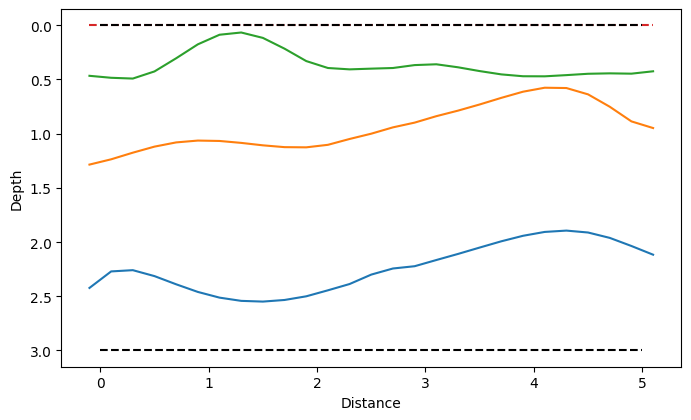

In [10]:
interface_sett= {
    'generate_surface':False,  # Generate ground surface

    # Parameters for step 1: Generation of rough interfaces
    'rough_interface_creator_instance':mg.rough_interface_creator2d.UniformInterfaceGen(1, rng=rng),
    'rough_interface_generator_scale': [0,1.3,1.2,1], 
    # If number of layers > length of list, last value is reused

    # Parameters for step 2: Filtering
    'filter_settings': {
                 'filter_window_length':21, # must be odd
                 'filter_polyorder':7,
                        },

    # Parameter for Step 3: Interface Initial Points Generation
    'interfaces_depths_generation':[0, 0.4, 1, 2.3], 
    'interfaces_depth_reference_point_x':2.5,
    
    # Parameter for Step 4: Handling the overlapping.
    'processing_settings': {
                'simulate_erosion': True,
            }
    }

n_layers = aux_props.aux_properties['n_layers'].generate()
gwt_depth = aux_props.aux_properties['gwt'].generate()

# DiscretizedInterfaces2D from dictionary definition
soil_interface = mg.DiscretizedInterfaces2DFromDict(domain_spatial, n_layers, interface_sett, remesh_interp_method=remesh_interp_method, rng=rng)
soil_interface.plot()

### Step 3.3: Lithological Domain (2D) Definition  
#### Step 3.3.1: From Interfaces (Global Soil Interface Configuration)

In this section, we first set and fix a global soil interface configuration.  
This global configuration is used internally and checked later to ensure the interface has not changed.

Important: For a single model, the global soil interface configuration must remain consistent throughout the workflow.

Once the global interface is fixed, we use a simple helper function to generate the 2D lithological domain directly from this global configuration.


<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

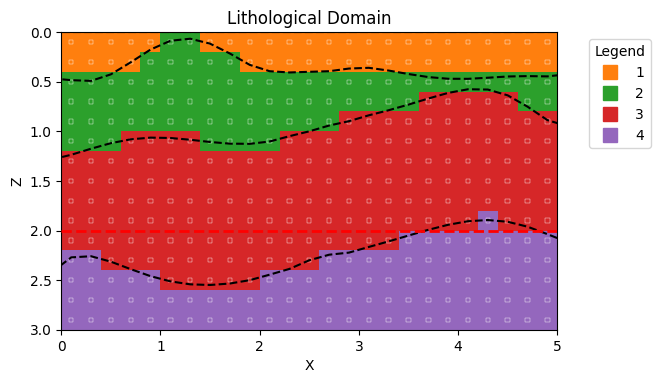

In [11]:
# Reset global soil interface configuration (safety step)
mg.GlobalSoilInterfaceConfig.reset()   # For safety only

# Register soil interface
mg.GlobalSoilInterfaceConfig.set_soil_interface(soil_interface)

## Get lithological domain from interface
name = 'soil_lit'
lit = mg.LithologicalDomain2D(domain_spatial, gwt_depth, name)
lit.plot(discrete_point_size = 10, plot_interfaces=True)

#### Step 3.3.2: From Obstruction2D (Global Soil Interface Configuration)

In this section, we first initialize a **`LithologicalDomain2DFromObstruction2D`** instance, which will be used to incrementally construct the lithological domain.  
For each subsurface feature, an obstruction is defined using the **`Obstruction2D`** class.

Random generators may be used to define the required parameters, such as the shape, size, and other geometric properties of the obstructions (if applicable).

Once an obstruction is defined, it is added to the previously initialized `LithologicalDomain2DFromObstruction2D` instance to update the lithological domain.

> Note: Skip this if no obstacles to be generated


F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\lithological_domain2d\a_base.py:275: UserWarning: Looks like the lit domain has been remeshed with linear after creation.
  warnings.warn("Looks like the lit domain has been remeshed with linear after creation.")


<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

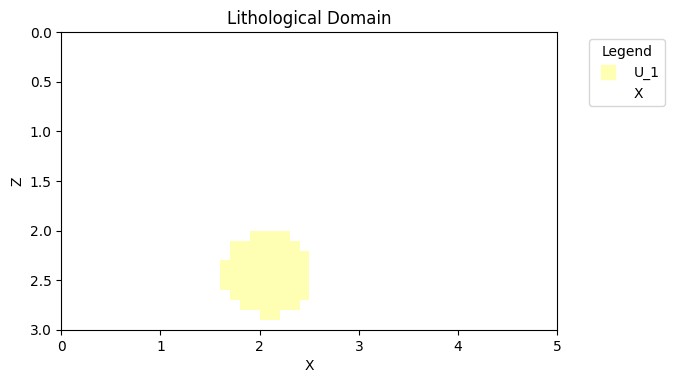

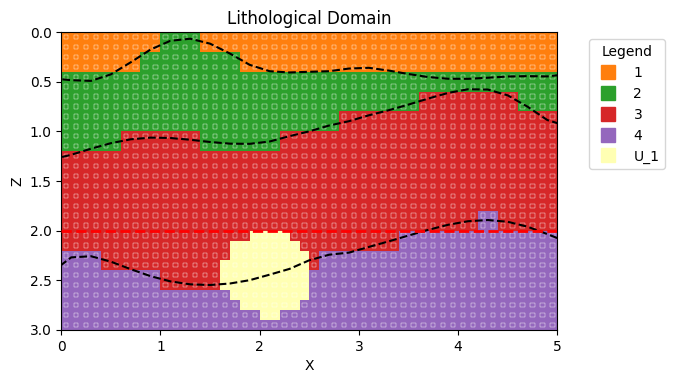

In [12]:
## Define a LithologicalDoamin2d From obstruction 2d.
obs_lit = mg.LithologicalDomain2DFromObstruction2D(domain_final, 'obstructions')

# Number of obstructions to generate
n_obs = aux_props.aux_properties['n_obs'].generate()

# Randomly generate obstruction shapes
obs_shapes = aux_props.aux_properties['obs_shape'].generate((n_obs,))

# For each obstruction, create a Obstruction2D instance first, and then add to obs_lit. 
for i, obs_shape in enumerate(obs_shapes):
    # Generate obstruction location
    obs_x_coord = aux_props.aux_properties['obs_x_coord'].generate()
    d_obs = aux_props.aux_properties['depth_top_utils'].generate()

    # Unique obstruction ID
    obs_id = i+1

    # Initialize Obstruction2D object
    obs_instance = mg.Obstruction2D(dl = del_xz_obs, ref_xz_symbolic = ['c', 0], snap_to_dl=True)

    # Define obstruction geometry
    if obs_shape == 'circ2d':
        d = aux_props.aux_properties['dia_obs'].generate()
        obs_instance.circle_2d(d, obstruction_id = obs_id)
    elif obs_shape == 'rect2d':
        lx = aux_props.aux_properties['lh_obs'].generate()
        lz = aux_props.aux_properties['lh_obs'].generate()
        obs_instance.rectangle_2d(lx, lz, obstruction_id = obs_id)
    else:
        raise ValueError(f"Invalid util_shape {obs_shape}")
    # obs_instance.plot()

    ## Add Obs2D into defnined lit_domain_from_obs2d 
    obs_lit.add_obstruction2D(obs_instance, shift_ref2d_to_xy = [obs_x_coord, d_obs], feature_id='U')

    # Plot lithological domain generated from obstructions (JUST FOR VISUALIZATION)
    obs_lit.plot()
    

# Visualize merged lithological domain (JUST FOR VISUALIZATION)
merged_lit = lit.return_merged_lithological_domain([obs_lit], warn_if_null_lithological_domain=False)  # Just to see how merged lit. Karst to be added later.
merged_lit.plot(discrete_point_size = 10, plot_interfaces=True)


### Step 3.4: Lithological Domain Collection

In this step, we combine multiple lithological domains (e.g., soil layers, karst features, utilities) into a single **lithological domain collection** class instance.

The `LithologicalDomain2DCollection` class:
- Acts as a **container** for all lithological domains used in the model
- Ensures **feature consistency** across domains
- Controls **merging order and validation**
- Prevents accidental modification once finalized

The collection is initialized using the list of feature IDs defined in the main properties configuration.  
The `interface_set_name` identifies the soil interface configuration used as the global reference.


In [13]:
# Initialize lithological domain collection
lit_collection = mg.LithologicalDomain2DCollection(main_properties_config_instance.get_feature_ids(), interface_set_name="soil") 

# Add soil-based lithological domain
lit_collection.add_lithological_domain_from_soil_interface_config(lit)
lit_collection.add_lithological_domain_from_obstruction2d("obs", obs_lit, warn_if_null_lithological_domain=False)

# Finalize and lock the lithological domain collection
lit_collection.lock()


### Step 4: Generate Simulated Property Profiles

For this example, we will generate **multiple realizations of the main property profiles** (`vs`) across the lithological domain.  

Key points "For this example":  
- Each realization uses the **same lithological domain and property distributions**.  
- The **spatial pattern varies** due to the spatial simulator, demonstrating variability in property fields.  
- We also manually override the top layer (`rock`) properties for this example.


In [14]:
lit_collection.lit_domain_set['soil'].lit_ids_expected

['1', '2', '3', '4']

In [15]:
# Unlock main properties config to allow sampling
main_properties_config_instance.unlock()

# Sample property values for all features in the lithological domain
main_properties_config_instance.lock_and_generate_sample_properties(lit_collection)
sample_properties = main_properties_config_instance.sampled_properties

sample_properties

{'ec': {'1': {'wet': {'mean': array([[27.74817693,  0.72182026]]),
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'},
   'dry': {'mean': array([[4.22689926, 0.01      ]]),
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'}},
  '2': {'wet': {'mean': array([[21.75566075,  0.18254719]]),
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'},
   'dry': {'mean': array([[3.75754705, 0.01      ]]),
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'}},
  '3': {'wet': {'mean': array([[27.1460405 ,  0.42926634]]),
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'},
   'dry': {'mean': array([[3.57458793, 0.01      ]]),
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'}},
  '4': {'wet': {'mean': array([[24.59746322,  0.17622956]]),
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'},
   'dry': {'mean': array([[3.1065386, 0.01     ]]),
    'mean_bm': 0,
    'stdev_or_cov': 0.05,

As illustrated above, two values are generated for 'ec', while 'dc' currently contains only a placeholder. Nevertheless, the data format remains consistent.

In other words, soil properties are represented as 'wet' and 'dry', whereas utilities use 'both'. Maintaining this consistent structure is essential.

The following steps perform post-processing to adjust and standardize the data format.

In [16]:
for lit_id in sample_properties['ec'].keys():
    for case in sample_properties['ec'][lit_id].keys():
        dc_ec = sample_properties['ec'][lit_id][case]['mean']
        dc, ec = float(dc_ec[0][0]), float(dc_ec[0][1])
        sample_properties['dc'][lit_id][case]['mean'] = dc
        sample_properties['ec'][lit_id][case]['mean'] = ec
main_properties_config_instance._sampled_properties = sample_properties

sample_properties

{'ec': {'1': {'wet': {'mean': 0.7218202636583563,
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'},
   'dry': {'mean': 0.01,
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'}},
  '2': {'wet': {'mean': 0.18254718720676694,
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'},
   'dry': {'mean': 0.01,
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'}},
  '3': {'wet': {'mean': 0.42926633722615565,
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'},
   'dry': {'mean': 0.01,
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'}},
  '4': {'wet': {'mean': 0.17622956236499027,
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'},
   'dry': {'mean': 0.01,
    'mean_bm': 0,
    'stdev_or_cov': 0.05,
    'stdev_type': 'cov'}},
  'U_1': {'both': {'mean': 0.001,
    'mean_bm': 0,
    'stdev_or_cov': 0,
    'stdev_type': 'cov'}}},
 'dc': {'1': {'wet': {'mean': 27.74817693151394,

In [17]:
# Initialize spatial simulator (controls spatial correlation)
spatial_sim = mg.spatial_simulator2d.CovarianceDecompositionSimulator(spatial_theta_x, spatial_theta_z, rng = rng)

# Generate property profiles using the spatial simulator
gen_profiles = mg.GeneratedProfileCollection2D(main_properties_config_instance, lit_collection, spatial_sim)
gen_profiles.simulate_property_profile('dc')        
gen_profiles.simulate_property_profile('ec')        

#Save the profiles into h5 files
i = 0
gen_profiles.save_to_hdf5(f'generated_h5_files/{i:08d}.h5', hdf5_compression_level=8)

Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 2
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 3
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 4
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_1
Simulating z-vals for Layer ID: X
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 1
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 2
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 3
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: 4
Z-vals: spatial-with-sigma
Simulating z-vals for Layer ID: U_1
Simulating z-vals for Layer ID: X
Data saved to generated_h5_files/00000000.h5


F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:348: UserWarning: Layer 2 (wet): sigma=1.087783037601438 but all simulated values are zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:348: UserWarning: Layer 1 (wet): sigma=1.387408846575697 but all simulated values are zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:306: UserWarning: Layer U_1: sigma=0 but 62 z-values are non-zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:348: UserWarning: Layer 2 (wet): sigma=0.009127359360338348 but all simulated values are zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\modgen2d\modgen2d\spatial_simulator2d.py:348: UserWarning: Layer 1 (wet): sigma=0.03609101318291782 but all simulated values are zero.
  warnings.warn(
F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\

(<Axes: title={'center': 'Main_property_name:dc'}, xlabel='X', ylabel='Z'>,
 np.float64(3.061507255747116),
 np.float64(28.44896405354483))

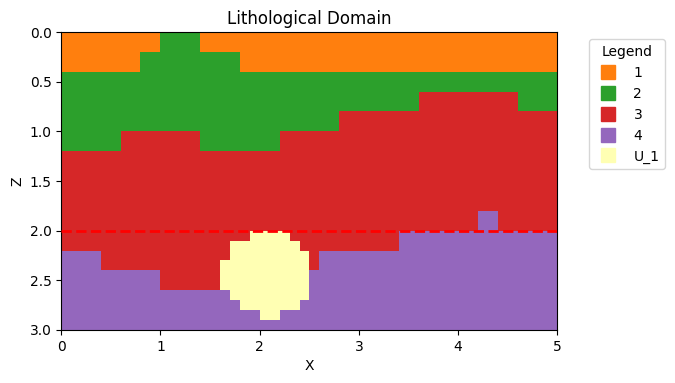

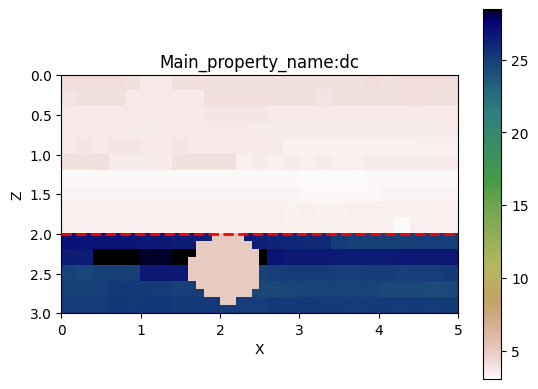

In [18]:
gen_profiles.merged_generated_model2d.plot_lit_domain()#'z_vals_seismic')
gen_profiles.merged_generated_model2d.plot_profile('dc')
# gen_profiles.get_generated_model2d('z_vals_seismic')

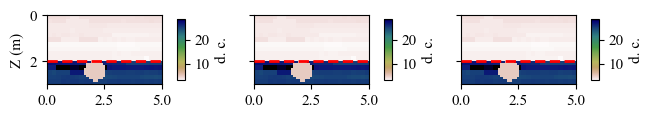

In [19]:
# Figure 7
import matplotlib
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=5)
matplotlib.rcParams['font.family'] = "serif"
matplotlib.rcParams['font.serif']= ['Times New Roman'] + plt.rcParams['font.serif']
matplotlib.rcParams['font.size'] = 11

fig, axs = plt.subplots(1, 3, figsize=(7, 10/4), sharex=True, sharey=True)

legendkwargs_dict = {
    'shrink':0.3,
    'aspect':8,
    'pad':0.1
}


ax = axs[0]
gen_profiles.merged_generated_model2d.plot_profile('dc', ax=ax, legend_label = 'd. c.', legendkwargs_dict=legendkwargs_dict)
ax.set(ylabel="Z (m)", xlabel=None, title=None)

ax = axs[1]
gen_profiles.merged_generated_model2d.plot_profile('dc', ax=ax, legend_label = 'd. c.', legendkwargs_dict=legendkwargs_dict)
ax.set(ylabel=None, xlabel=None, title=None)

ax = axs[2]
gen_profiles.merged_generated_model2d.plot_profile('dc', ax=ax, legend_label = 'd. c.', legendkwargs_dict=legendkwargs_dict)
ax.set(ylabel=None, xlabel=None, title=None)

# ax = axs[1]
# gen_profiles.merged_generated_model2d.plot_profile('miu', ax=ax)

fig.tight_layout(rect=[0.05, 0.05, 1, 1])  # Leave space for shared labels
fig.savefig(r"F:\V_Tech Semesters\MS Thesis\Jupyter_MS\Papers_figures\Geomodgen2d_paper\Figure10_raw.svg", format="svg", bbox_inches='tight', metadata={'Creator':'Matplotlib'})

# ax.set(yscale='log', ylabel=None, xlabel=None, ylim=[0,1], title=None)

